# Comparing Speculative Decoding Methods Across Different Gamma

This notebook studies the impact of draft length Gamma for each speculative decoding method
(`standard`, `naive_hsd`, `capped_hsd`) and plots generation speed
(tokens / second) as a function of Gamma, with the target-model-only baseline
as a reference line.

In [1]:
import torch
import matplotlib.pyplot as plt

from seqspecdecod import load_models, baseline_generate, speculative_generate

if torch.cuda.is_available():
    DEVICE = "cuda"

print(f"Using device: {DEVICE}")

c:\Users\yijin\anaconda3\envs\spec_decode\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
tokenizer, draft_model, target_model = load_models(
    draft_name="Qwen/Qwen3-0.6B",
    target_name="Qwen/Qwen3-4B",
    device=DEVICE,
)

Loading tokenizer from Qwen/Qwen3-0.6B


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading draft model: (Qwen/Qwen3-0.6B)


Loading weights: 100%|██████████| 311/311 [00:02<00:00, 142.95it/s]


Loading target model: (Qwen/Qwen3-4B)


Loading weights: 100%|██████████| 398/398 [00:08<00:00, 44.26it/s]


## Configurations

In [3]:
PROMPTS = [
    "Give me a short introduction to large language models.",
    "Explain the difference between supervised and unsupervised learning.",
    "What is the transformer architecture and why is it so popular?",
    "What is gradient descent and how does it work?",
]

GAMMAS = [3, 5, 10, 15, 20]
METHODS = ["standard", "naive_hsd", "capped_hsd"]
MAX_NEW_TOKENS = 200
DRAFT_TEMPERATURE = 0.6
TARGET_TEMPERATURE = 0.6

## Baseline (target model only)

The baseline speed does not depend on Gamma, so we only need to measure it once (averaged over
all prompts) and draw it as a horizontal reference line in the plot.

In [4]:
# warmup first
baseline_generate(target_model, tokenizer, "Hello.", max_new_tokens=10,
                  target_temperature=TARGET_TEMPERATURE)

baseline_speeds = []
for prompt in PROMPTS:
    r = baseline_generate(
        target_model, tokenizer, prompt,
        max_new_tokens=MAX_NEW_TOKENS,
        target_temperature=TARGET_TEMPERATURE,
    )
    baseline_speeds.append(r["tokens_per_sec"])
    print(f"baseline: {r['tokens_per_sec']:6.1f} tok/s  ({r['tokens_generated']} tokens)")

baseline_tok_per_sec = sum(baseline_speeds) / len(baseline_speeds)
print(f"\nBaseline average: {baseline_tok_per_sec:.1f} tok/s")

baseline:    2.6 tok/s  (129 tokens)
baseline:    2.0 tok/s  (200 tokens)
baseline:    1.5 tok/s  (200 tokens)
baseline:    1.5 tok/s  (200 tokens)

Baseline average: 1.9 tok/s


## Speculative Decoding

For every (method, Gamma) pair we generate on all prompts and average tokens/sec,
acceptance rate, and accepted tokens per round.

In [5]:
results = {m: {} for m in METHODS}
failures = []

# warmup the speculative path once
speculative_generate(
    draft_model, target_model, tokenizer, "Hello.",
    max_new_tokens=10, gamma=2, method="standard",
    draft_temperature=DRAFT_TEMPERATURE, target_temperature=TARGET_TEMPERATURE,
)

for method in METHODS:
    for gamma in GAMMAS:
        speeds, acc_rates, accepted_ns = [], [], []
        try:
            for prompt in PROMPTS:
                r = speculative_generate(
                    draft_model, target_model, tokenizer, prompt,
                    max_new_tokens=MAX_NEW_TOKENS,
                    gamma=gamma,
                    method=method,
                    draft_temperature=DRAFT_TEMPERATURE,
                    target_temperature=TARGET_TEMPERATURE,
                )
                speeds.append(r["tokens_per_sec"])
                acc_rates.append(r["acceptance_rate"])
                accepted_ns.append(r["average_accepted_n"])
        except Exception:
            failures.append((method, gamma))
            print(f"[FAILED] {method:12s} gamma={gamma}")
            continue

        results[method][gamma] = {
            "tokens_per_sec": sum(speeds) / len(speeds),
            "acceptance_rate": sum(acc_rates) / len(acc_rates),
            "average_accepted_n": sum(accepted_ns) / len(accepted_ns),
        }
        print(f"{method:12s} gamma={gamma}: "
              f"{results[method][gamma]['tokens_per_sec']:6.1f} tok/s, "
              f"acceptance {results[method][gamma]['acceptance_rate']:.1%}, "
              f"avg accepted {results[method][gamma]['average_accepted_n']:.2f}")

if failures:
    print(f"\nFailed runs (skipped): {failures}")

standard     gamma=3:    3.2 tok/s, acceptance 55.7%, avg accepted 1.67
standard     gamma=5:    3.2 tok/s, acceptance 43.1%, avg accepted 2.16
standard     gamma=10:    3.0 tok/s, acceptance 28.1%, avg accepted 2.81
standard     gamma=15:    2.5 tok/s, acceptance 20.2%, avg accepted 3.04
standard     gamma=20:    1.9 tok/s, acceptance 13.5%, avg accepted 2.69
naive_hsd    gamma=3:    1.7 tok/s, acceptance 49.7%, avg accepted 1.49
naive_hsd    gamma=5:    1.8 tok/s, acceptance 49.4%, avg accepted 2.47
naive_hsd    gamma=10:    1.5 tok/s, acceptance 30.4%, avg accepted 3.04
naive_hsd    gamma=15:    1.5 tok/s, acceptance 19.1%, avg accepted 2.87
naive_hsd    gamma=20:    1.3 tok/s, acceptance 15.8%, avg accepted 3.15
capped_hsd   gamma=3:    3.7 tok/s, acceptance 67.7%, avg accepted 2.03
capped_hsd   gamma=5:    3.7 tok/s, acceptance 52.4%, avg accepted 2.62
capped_hsd   gamma=10:    3.6 tok/s, acceptance 36.8%, avg accepted 3.68
capped_hsd   gamma=15:    2.9 tok/s, acceptance 24.6%, av

## Plot: tokens/sec vs Gamma

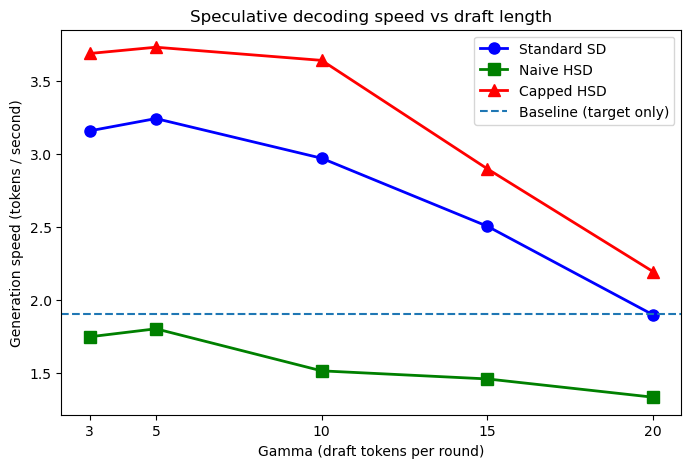

In [8]:
# Fixed color per method (colorblind-validated ordering; identity never cycles)
METHOD_COLORS = {
    "standard": 'blue',
    "naive_hsd": 'green',
    "capped_hsd": 'red',
}
METHOD_MARKERS = {"standard": "o", "naive_hsd": "s", "capped_hsd": "^"}
METHOD_LABELS = {
    "standard": "Standard SD",
    "naive_hsd": "Naive HSD",
    "capped_hsd": "Capped HSD",
}

fig, ax = plt.subplots(figsize=(8, 5))

for method in METHODS:
    pts = sorted(results[method].items())
    xs = [g for g, _ in pts]
    ys = [v["tokens_per_sec"] for _, v in pts]
    ax.plot(xs, ys, color=METHOD_COLORS[method], marker=METHOD_MARKERS[method],
            markersize=8, linewidth=2, label=METHOD_LABELS[method])

ax.axhline(baseline_tok_per_sec, linewidth=1.5,
           linestyle="--", label="Baseline (target only)")

ax.set_xlabel("Gamma (draft tokens per round)")
ax.set_ylabel("Generation speed (tokens / second)")
ax.set_title("Speculative decoding speed vs draft length")
ax.set_xticks(GAMMAS)

ax.legend()

plt.savefig(
    "../docs/speculative_decoding_speed.pdf", 
    dpi=300,                          
    bbox_inches="tight"               
)

plt.show()